# train the model using bert -------->>> symptoms analysis agent

In [ ]:
!pip uninstall -y torch torchvision torchaudio transformers
!pip install torch==2.1.0 torchvision torchaudio
!pip install transformers==4.38.2

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install transformers torch pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [ ]:
import pandas as pd
import torch
import numpy as np
import random
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter

# ==========================================
# 1. Setup
# ==========================================
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. Data Loading & Cleaning
# ==========================================
df = pd.read_csv('combined_symptoms_dataset.csv')

# Fill missing values
df['symptoms'] = df['symptoms'].fillna('no specific symptoms reported')
df['symptoms'] = df['symptoms'].replace('', 'no specific symptoms reported')

# Encode Labels
label_map = {'Normal': 0, 'COVID': 1, 'Pneumonia': 2, 'TB': 3}
df['label'] = df['disease'].map(label_map)

print(f"Class distribution:\n{df['disease'].value_counts()}")

# Split Data
X_train, X_val, y_train, y_val = train_test_split(
    df['symptoms'].values,
    df['label'].values,
    test_size=0.15,   # Slightly smaller val set to give more data for training
    random_state=42,
    stratify=df['label'].values
)

# ==========================================
# 3. Tokenization (UPGRADED: ClinicalBERT)
# ==========================================
print("Loading ClinicalBERT tokenizer...")
# UPGRADE: Using 'emilyalsentzer/Bio_ClinicalBERT' instead of standard BERT
tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

def preprocessing_for_bert(data):
    input_ids = []
    attention_masks = []
    for sent in data:
        encoded_sent = tokenizer(
            text=sent,
            add_special_tokens=True,
            max_length=128,      # Increased context window
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    return torch.tensor(input_ids), torch.tensor(attention_masks)

print("Tokenizing data...")
train_inputs, train_masks = preprocessing_for_bert(X_train)
val_inputs, val_masks = preprocessing_for_bert(X_val)

train_labels = torch.tensor(y_train)
val_labels = torch.tensor(y_val)

# ==========================================
# 4. Handle Class Imbalance (UPGRADED)
# ==========================================
# Calculate weights for each class to penalize the model for misclassifying minority classes
class_counts = Counter(y_train)
num_classes = len(class_counts)
class_weights = [0] * num_classes

# Inverse frequency weighting
for cls, count in class_counts.items():
    class_weights[cls] = 1.0 / count

# Assign weight to each sample in the training set
sample_weights = [class_weights[label] for label in y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 16 # Reduced batch size for better gradient updates on small data

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(train_data, sampler=sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_dataloader = DataLoader(val_data, batch_size=batch_size)

# ==========================================
# 5. Model Initialization (ClinicalBERT)
# ==========================================
print("Initializing ClinicalBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT",
    num_labels=4,
)
model.to(device)

# Optimizer with slightly higher learning rate for faster adaptation
optimizer = AdamW(model.parameters(), lr=3e-5, eps=1e-8)
epochs = 1 # Increased epochs
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# ==========================================
# 6. Training Loop
# ==========================================
def train(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        model.zero_grad()
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    val_accuracy = []
    val_loss = []
    for batch in dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits
        val_loss.append(loss.item())
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        preds = np.argmax(logits, axis=1).flatten()
        labels_flat = label_ids.flatten()
        val_accuracy.append((preds == labels_flat).mean())
    return np.mean(val_loss), np.mean(val_accuracy)

print("\nTraining Started...")
best_accuracy = 0

for epoch_i in range(0, epochs):
    print(f'\n======== Epoch {epoch_i + 1} / {epochs} ========')
    train_loss = train(model, train_dataloader, optimizer, scheduler, device)
    val_loss, val_acc = evaluate(model, val_dataloader, device)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc*100:.2f}%")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        # Save the best model
        model.save_pretrained("./best_lung_disease_model")
        tokenizer.save_pretrained("./best_lung_disease_model")

print("\nTraining complete!")
print(f"Best Validation Accuracy: {best_accuracy*100:.2f}%")

# ==========================================
# 7. Final Evaluation
# ==========================================
model.eval()
predictions , true_labels = [], []
for batch in val_dataloader:
    batch = tuple(t.to(device) for t in batch)
    b_input_ids, b_input_mask, b_labels = batch
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    predictions.append(logits)
    true_labels.append(label_ids)

flat_predictions = [item for sublist in predictions for item in sublist]
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()
flat_true_labels = [item for sublist in true_labels for item in sublist]

print("\nFinal Classification Report:")
target_names = ['Normal', 'COVID', 'Pneumonia', 'TB']
print(classification_report(flat_true_labels, flat_predictions, target_names=target_names))

Using device: cuda
Class distribution:
disease
COVID        1271
TB           1000
Normal        419
Pneumonia     408
Name: count, dtype: int64
Loading ClinicalBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizing data...
Initializing ClinicalBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training Started...

======== Epoch 1 / 1 ========
Train Loss: 0.2924
Validation Loss: 0.1237
Validation Accuracy: 96.25%

Training complete!
Best Validation Accuracy: 96.25%

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.90      0.86        63
       COVID       0.97      0.94      0.95       191
   Pneumonia       1.00      0.98      0.99        61
          TB       1.00      1.00      1.00       150

    accuracy                           0.96       465
   macro avg       0.95      0.96      0.95       465
weighted avg       0.96      0.96      0.96       465



In [ ]:
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Create the final destination directory
final_text_model_path = './saved_models/text_agent_bert'
os.makedirs(final_text_model_path, exist_ok=True)

# 2. Load the best model that was just saved during training
# (The training loop saved it to "./best_lung_disease_model")
print("Loading best model from training checkpoint...")
model_text = AutoModelForSequenceClassification.from_pretrained("./best_lung_disease_model")
tokenizer_text = AutoTokenizer.from_pretrained("./best_lung_disease_model")

# 3. Save it to the final standardized folder
model_text.save_pretrained(final_text_model_path)
tokenizer_text.save_pretrained(final_text_model_path)

print(f"✅ Text Model successfully saved to: {final_text_model_path}")

Loading best model from training checkpoint...
✅ Text Model successfully saved to: ./saved_models/text_agent_bert


# **lab report analysis agent -----------------> using XGboost**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# ==========================================
# 1. Load Data
# ==========================================
# Assuming you have the file, otherwise load the dataframe manually
df = pd.read_excel('lung_disease.xlsx')

# For this example, I'm creating the dataframe from your provided text logic
# (In your actual code, just use: df = pd.read_excel('lung_disease.xlsx'))
# Here I assume 'df' is already loaded.

# ==========================================
# 2. Critical Data Cleaning (For High Accuracy)
# ==========================================
print("Starting Data Cleaning...")

# A. Drop irrelevant columns
if 'Patient' in df.columns:
    df = df.drop(['Patient'], axis=1)

# B. Fix Outliers in Numerical Columns
# FVC and FEC1 are lung volumes. Normal range is 1.0 to 6.0 Liters.
# Values like 70.0, 80.0 in FEC1 are clearly data entry errors (likely misplaced decimals).
# We will cap values > 10 to NaN and fill with median to prevent model confusion.

def clean_outliers(df, column, upper_limit=10.0):
    # Convert to numeric, coerce errors to NaN
    df[column] = pd.to_numeric(df[column], errors='coerce')
    # Replace impossible values with NaN
    df.loc[df[column] > upper_limit, column] = np.nan
    # Fill NaN with the median of valid data
    median_val = df[column].median()
    df[column] = df[column].fillna(median_val)
    return df

df = clean_outliers(df, 'FEC1', upper_limit=10.0)
df = clean_outliers(df, 'FVC', upper_limit=10.0)
df = clean_outliers(df, 'AGE', upper_limit=120) # Clean Age just in case

# C. Handle 'Scan' Column (Categorical)
# Fill missing scans if any
df['Scan'] = df['Scan'].fillna('Unknown')

# D. Encode Binary Categorical Columns (T/F -> 1/0)
binary_cols = ['smoke', 'PEFR', 'O2', 'ABG-P-O2', 'ABG-P-CO2', 'ABG-pH Level', 'Asthama', 'Other diseaes']
for col in binary_cols:
    df[col] = df[col].map({'T': 1, 'F': 0, True: 1, False: 0})
    # Fill any remaining NaNs with 0 (assuming missing = False/Normal)
    df[col] = df[col].fillna(0).astype(int)

# E. Encode Target Variable ('Risk')
# T = High Risk (1), F = Low Risk (0)
df['Risk'] = df['Risk'].map({'T': 1, 'F': 0})

# F. One-Hot Encode 'Scan' Column
df = pd.get_dummies(df, columns=['Scan'], drop_first=True)

print("Data Cleaning Complete.")
print(f"Cleaned Data Shape: {df.shape}")

# ==========================================
# 3. Split Data
# ==========================================
X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 4. Train XGBoost Model
# ==========================================
print("Training XGBoost Model...")

# Using optimized parameters for small/medium tabular data
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 5. Evaluate
# ==========================================
preds = model.predict(X_val)
probs = model.predict_proba(X_val)[:, 1] # Get probability of class 1 (High Risk)

acc = accuracy_score(y_val, preds)
print(f"\n✅ Model Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_val, preds))

Starting Data Cleaning...
Data Cleaning Complete.
Cleaned Data Shape: (470, 14)
Training XGBoost Model...

✅ Model Accuracy: 80.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        80
           1       0.17      0.07      0.10        14

    accuracy                           0.81        94
   macro avg       0.51      0.50      0.50        94
weighted avg       0.75      0.81      0.77        94



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:20:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data
df = pd.read_excel('lung_disease.xlsx')

# 2. Preprocessing
if 'Patient' in df.columns: df = df.drop(['Patient'], axis=1)

# Clean Outliers
def clean_outliers(df, column, upper_limit=10.0):
    df[column] = pd.to_numeric(df[column], errors='coerce')
    df.loc[df[column] > upper_limit, column] = np.nan
    df[column] = df[column].fillna(df[column].median())
    return df

df = clean_outliers(df, 'FEC1', upper_limit=10.0)
df = clean_outliers(df, 'FVC', upper_limit=10.0)
df = clean_outliers(df, 'AGE', upper_limit=120)
df['Scan'] = df['Scan'].fillna('Unknown')

# Encode Binary
binary_cols = ['smoke', 'PEFR', 'O2', 'ABG-P-O2', 'ABG-P-CO2', 'ABG-pH Level', 'Asthama', 'Other diseaes']
for col in binary_cols:
    df[col] = df[col].map({'T': 1, 'F': 0}).fillna(0).astype(int)

df['Risk'] = df['Risk'].map({'T': 1, 'F': 0})

# One-Hot Encode Scan
df = pd.get_dummies(df, columns=['Scan'], drop_first=True)

# 3. Split
X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train XGBoost (Using distinct variable name 'lab_model')
lab_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, use_label_encoder=False, eval_metric='logloss')
lab_model.fit(X_train, y_train)

# Evaluate
preds = lab_model.predict(X_val)
print(f"Lab Agent Accuracy: {accuracy_score(y_val, preds)*100:.2f}%")

# 5. Save Correctly
import os
os.makedirs('./saved_models', exist_ok=True)

joblib.dump(lab_model, './saved_models/lab_agent_xgb.pkl')
joblib.dump(X.columns.tolist(), './saved_models/lab_columns.pkl')

print("✅ Lab Model (XGBoost) Saved Correctly.")

Lab Agent Accuracy: 80.85%
✅ Lab Model (XGBoost) Saved Correctly.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:20:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import joblib

# Save XGBoost model
joblib.dump(model, './saved_models/lab_agent_xgb.pkl')

# Save the columns (CRITICAL for ensuring input order is correct later)
# If X is not defined, replace with the list of columns you used for training
try:
    joblib.dump(X.columns.tolist(), './saved_models/lab_columns.pkl')
    print("✅ Lab Model Saved (XGBoost)")
except:
    print("❌ Error: Variable 'X' not found. Please run the Lab Agent training code again.")

✅ Lab Model Saved (XGBoost)


# **image analysis agent--------->VGG 16**

In [ ]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import shutil

# libraries for CNN models and plotting
import tensorflow as tf
import tensorflow.keras.layers as tfl

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openpyxl

In [ ]:
SAMPLE_SIZE = 1345
BATCH_SIZE = 32
IMG_SIZE = (256  , 256)
train_directory = '/content/drive/MyDrive/Lung Disease Dataset/train'
val_directory = '/content/drive/MyDrive/Lung Disease Dataset/val'

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
        rotation_range=0.2,
        shear_range=0.2,
        horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
        train_directory,
        target_size=IMG_SIZE,
        color_mode='grayscale',
        batch_size=32,
        class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(
        val_directory,
        target_size=IMG_SIZE,
        color_mode='grayscale',
        batch_size=32,
        shuffle=False,
        class_mode='categorical')

Found 4849 images belonging to 4 classes.
Found 1615 images belonging to 4 classes.


In [ ]:
train_generator.class_indices

{'Corona Virus Disease': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}

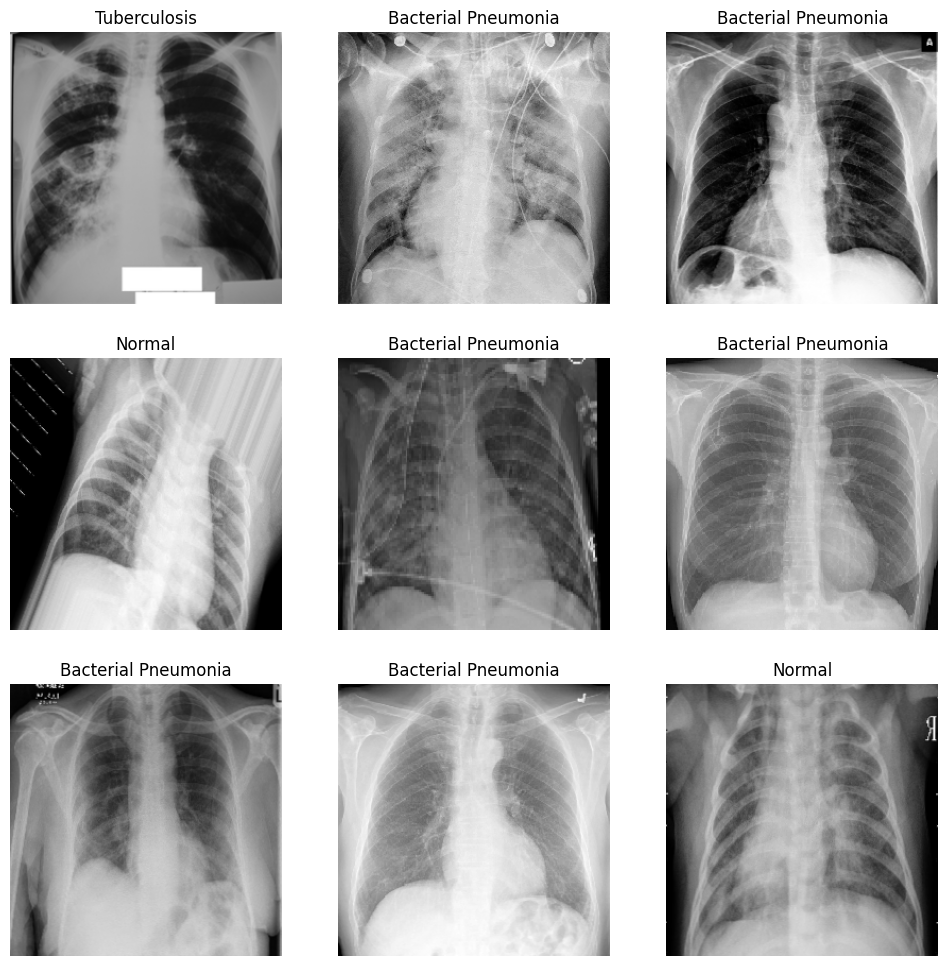

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Use __next__() instead of next()
    img, label = train_generator.__next__()
    plt.imshow(img[0], cmap='gray')
    dic = {0: 'Bacterial Pneumonia', 1: 'Corona Virus Disease', 2: 'Normal', 3: 'Tuberculosis'}
    plt.title(dic.get(np.where(label[0] == 1)[0][0]))
    plt.axis('off')
plt.show()

In [ ]:
!pip install lungmask
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 128.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# --- Configuration ---
original_train_dir = '/content/drive/MyDrive/Lung Disease Dataset/train'
original_val_dir = '/content/drive/MyDrive/Lung Disease Dataset/val'
processed_dir = '/content/drive/MyDrive/Lung Disease Dataset/Processed_Masked'

def apply_lung_mask_opencv(input_path, output_path):
    """
    Isolates the lungs by finding the main body contour
    and removing the background.
    """
    try:
        # 1. Read image in Grayscale
        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None: return

        # 2. Thresholding to separate body from background
        # Anything > 20 intensity is considered body
        _, binary = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)

        # 3. Find Contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # 4. Keep the largest contour (The Torso)
            # This removes text, wires, and small noise outside the body
            max_contour = max(contours, key=cv2.contourArea)

            # Create a mask for the largest contour
            mask = np.zeros_like(img)
            cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)

            # 5. Apply mask to original image
            result = cv2.bitwise_and(img, img, mask=mask)
        else:
            result = img # Fallback

        # Save the processed image
        cv2.imwrite(output_path, result)

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

def process_directory(source_dir, target_dir):
    if os.path.exists(target_dir):
        print(f"Directory {target_dir} already exists. Skipping preprocessing.")
        return

    os.makedirs(target_dir, exist_ok=True)
    classes = os.listdir(source_dir)

    for cls in classes:
        class_path = os.path.join(source_dir, cls)
        save_path = os.path.join(target_dir, cls)
        os.makedirs(save_path, exist_ok=True)

        print(f"Processing class: {cls}")
        images = os.listdir(class_path)
        for img_name in tqdm(images):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(save_path, img_name)
            apply_lung_mask_opencv(src, dst)

# Run Preprocessing
print("Starting Lung Isolation (OpenCV)...")
process_directory(original_train_dir, os.path.join(processed_dir, 'train'))
process_directory(original_val_dir, os.path.join(processed_dir, 'val'))
print("Preprocessing Complete!")

Starting Lung Isolation (OpenCV)...
Directory /content/drive/MyDrive/Lung Disease Dataset/Processed_Masked/train already exists. Skipping preprocessing.
Directory /content/drive/MyDrive/Lung Disease Dataset/Processed_Masked/val already exists. Skipping preprocessing.
Preprocessing Complete!


Found 4849 images belonging to 4 classes.
Found 1615 images belonging to 4 classes.
152/152 ━━━━━━━━━━━━━━━━━━━━ 157s 962ms/step - accuracy: 0.8360 - loss: 0.4711 - val_accuracy: 0.8997 - val_loss: 0.2739 - learning_rate: 0.0010


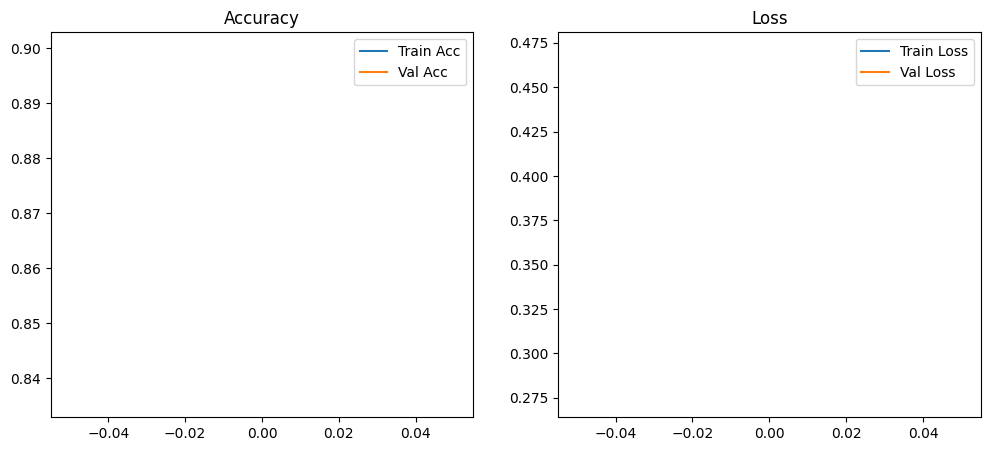

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- Configuration ---
IMG_SIZE = (224, 224) # VGG16 requires 224x224
BATCH_SIZE = 32

train_directory = '/content/drive/MyDrive/Lung Disease Dataset/Processed_Masked/train'
val_directory = '/content/drive/MyDrive/Lung Disease Dataset/Processed_Masked/val'

# --- Data Generators ---
# VGG16 needs RGB (3 channels), so color_mode='rgb'
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_directory,
    target_size=IMG_SIZE,
    color_mode='rgb',     # Changed to rgb
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    val_directory,
    target_size=IMG_SIZE,
    color_mode='rgb',     # Changed to rgb
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Build VGG16 Model ---
# Load VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (so we don't destroy pre-trained weights)
for layer in base_model.layers:
    layer.trainable = False

# Build the classifier on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax') # 4 Classes: Normal, Pneumonia, COVID, TB
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# --- Train ---
history = model.fit(
    train_generator,
    epochs=1,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr]
)

# --- Plot Results ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
# Save the Keras model
model.save('./saved_models/image_agent_vgg16.h5')
print("Image Model Saved to ./saved_models/image_agent_vgg16.h5")

Image Model Saved to ./saved_models/image_agent_vgg16.h5


# Agent building

------> X-ray image
        symptoms
        labreport

Agent communication....         
                

     

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. IMAGE AGENT
# ==========================================
class ImageAgent:
    def __init__(self, model_path):
        print("Loading Image Agent...")
        self.model = load_model(model_path)
        self.labels = ['COVID', 'Normal', 'Pneumonia', 'TB']
        print("Image Agent Ready.")

    def preprocess(self, img_path):
        # 1. Load Grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: raise FileNotFoundError(f"Image not found: {img_path}")

        # 2. Apply Lung Mask (Thresholding method from training)
        _, binary = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            max_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(img)
            cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)
            img = cv2.bitwise_and(img, img, mask=mask)

        # 3. Convert to RGB (VGG16 requirement)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # 4. Resize and Normalize
        img = cv2.resize(img, (224, 224))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=0)
        return img

    def predict(self, img_path):
        processed_img = self.preprocess(img_path)
        preds = self.model.predict(processed_img, verbose=0)[0]

        # Map predictions to labels
        # Assuming flow_from_directory sorted order: COVID, Normal, Pneumonia, TB
        result = {
            "Normal": float(preds[self.labels.index('Normal')]),
            "Pneumonia": float(preds[self.labels.index('Pneumonia')]),
            "COVID": float(preds[self.labels.index('COVID')]),
            "TB": float(preds[self.labels.index('TB')])
        }
        return result

# ==========================================
# 2. TEXT AGENT
# ==========================================
class TextAgent:
    def __init__(self, model_path):
        print("Loading Text Agent...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model.to(self.device)
        self.model.eval()
        # Mapping based on training: 0:Normal, 1:COVID, 2:Pneumonia, 3:TB
        self.id2label = {0: 'Normal', 1: 'COVID', 2: 'Pneumonia', 3: 'TB'}
        print("Text Agent Ready.")

    def predict(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
        # Move inputs to device
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

        result = {
            "Normal": float(probs[0]),
            "Pneumonia": float(probs[2]),
            "COVID": float(probs[1]),
            "TB": float(probs[3])
        }
        return result

# ==========================================
# 3. LAB AGENT
# ==========================================
import joblib
import pandas as pd
import numpy as np

class LabAgent:
    def __init__(self, model_path, columns_path):
        print("Loading Lab Agent...")
        self.model = joblib.load(model_path)
        self.columns = joblib.load(columns_path)

        # Safety Check: Ensure we loaded an XGBoost model, not Keras
        if not hasattr(self.model, 'predict_proba'):
            raise TypeError("Loaded model is not XGBoost (missing predict_proba). Please re-run the saving script above.")

        self.binary_cols = ['smoke', 'PEFR', 'O2', 'ABG-P-O2', 'ABG-P-CO2', 'ABG-pH Level', 'Asthama', 'Other diseaes']
        print("Lab Agent Ready.")

    def predict(self, data_dict):
        # 1. Create DataFrame
        df = pd.DataFrame([data_dict])

        # 2. Binary Mapping
        for col in self.binary_cols:
            if col in df.columns:
                df[col] = df[col].map({'T': 1, 'F': 0, 1:1, 0:0})
            else:
                df[col] = 0

        # 3. One-Hot Encode 'Scan'
        if 'Scan' in df.columns:
            scan_dummies = pd.get_dummies(df['Scan'], prefix='Scan')
            df = pd.concat([df.drop('Scan', axis=1), scan_dummies], axis=1)

        # 4. Align Columns (Critical for XGBoost)
        df = df.reindex(columns=self.columns, fill_value=0)

        # 5. Predict
        prob_high = self.model.predict_proba(df)[0][1] # Probability of Class 1 (High Risk)

        if prob_high >= 0.7: risk = "High"
        elif prob_high >= 0.4: risk = "Medium"
        else: risk = "Low"

        return {"risk": risk, "score": round(float(prob_high), 2)}

# ==========================================
# 4. AGENT COMMUNICATION / ORCHESTRATION
# ==========================================
class DiagnosisSystem:
    def __init__(self):
        self.img_agent = ImageAgent('./saved_models/image_agent_vgg16.h5')
        self.txt_agent = TextAgent('./saved_models/text_agent_bert')
        self.lab_agent = LabAgent('./saved_models/lab_agent_xgb.pkl', './saved_models/lab_columns.pkl')

    # 🔹 Normalize probabilities
    def normalize(self, res):
        total = sum(res.values())
        if total == 0:
            return res
        return {k: v / total for k, v in res.items()}

    # 🔹 Agent Communication Logic
    def apply_communication(self, img_res, txt_res, shared_memory):

        # Rule 1: Symptoms → Image
        if shared_memory["fever"] and shared_memory["cough"]:
            img_res["Pneumonia"] += 0.05
            img_res["COVID"] += 0.05

        # Rule 2: Image → Text
        if shared_memory["image_abnormal"]:
            txt_res["Pneumonia"] += 0.05
            txt_res["TB"] += 0.05

        # Rule 3: Lab Risk → All
        if shared_memory["risk"] == "High":
            for k in img_res:
                img_res[k] += 0.05
            for k in txt_res:
                txt_res[k] += 0.05

        # Normalize after update
        img_res = self.normalize(img_res)
        txt_res = self.normalize(txt_res)

        return img_res, txt_res

    # 🔹 Final Decision Fusion
    def final_decision(self, img_res, txt_res, lab_res):

        risk_map = {"Low": 0.2, "Medium": 0.5, "High": 0.8}
        risk_value = risk_map[lab_res["risk"]]

        # 🔥 Dynamic weights (better than fixed)
        w1 = max(img_res.values())  # confidence of image
        w2 = max(txt_res.values())  # confidence of text
        w3 = risk_value

        # Normalize weights
        total = w1 + w2 + w3
        w1, w2, w3 = w1/total, w2/total, w3/total

        final_scores = {}

        for disease in img_res:
            final_scores[disease] = (
                w1 * img_res[disease] +
                w2 * txt_res[disease] +
                w3 * risk_value
            )

        final_disease = max(final_scores, key=final_scores.get)

        return final_disease, round(final_scores[final_disease], 3), final_scores

    # 🔹 Main Diagnose Function
    def diagnose(self, img_path, symptom_text, lab_data):

        print("\n" + "="*40)
        print("MULTI-AGENT DIAGNOSIS SYSTEM")
        print("="*40)

        shared_memory = {}

        # -----------------------------
        # 1. IMAGE AGENT
        # -----------------------------
        img_res = self.img_agent.predict(img_path)
        print("\n[Image Agent Output]")
        print(img_res)

        # Store insight
        shared_memory["image_abnormal"] = max(img_res.values()) > 0.6

        # -----------------------------
        # 2. TEXT AGENT
        # -----------------------------
        txt_res = self.txt_agent.predict(symptom_text)
        print("\n[Text Agent Output]")
        print(txt_res)

        # Store insights
        symptom_text_lower = symptom_text.lower()
        shared_memory["fever"] = "fever" in symptom_text_lower
        shared_memory["cough"] = "cough" in symptom_text_lower

        # -----------------------------
        # 3. LAB AGENT
        # -----------------------------
        lab_res = self.lab_agent.predict(lab_data)
        print("\n[Lab Agent Output]")
        print(lab_res)

        shared_memory["risk"] = lab_res["risk"]

        # -----------------------------
        # 4. AGENT COMMUNICATION
        # -----------------------------
        img_res, txt_res = self.apply_communication(img_res, txt_res, shared_memory)

        print("\n[After Agent Communication]")
        print("Updated Image:", img_res)
        print("Updated Text :", txt_res)

        # -----------------------------
        # 5. FINAL DECISION
        # -----------------------------
        final_disease, confidence, all_scores = self.final_decision(img_res, txt_res, lab_res)

        print("\n" + "="*40)
        print("FINAL RESULT")
        print("="*40)
        print("Disease   :", final_disease)
        print("Confidence:", confidence)
        print("Severity  :", lab_res["risk"])

        return {
            "final_disease": final_disease,
            "confidence": confidence,
            "severity": lab_res["risk"],
            "all_scores": all_scores,
            "image_agent": img_res,
            "text_agent": txt_res,
            "lab_agent": lab_res
        }

# ==========================================
# 5. USAGE
# ==========================================

# Example Inputs
sample_img = '/content/drive/MyDrive/Lung Disease Dataset/val/Tuberculosis/test_0_109.jpeg' # CHANGE THIS PATH
sample_symptoms = "high fever dry cough difficulty breathing"
sample_lab_data = {
    'smoke': 'F', 'FVC': 2.5, 'FEC1': 1.8, 'PEFR': 'F', 'O2': 'F',
    'ABG-P-O2': 'T', 'ABG-P-CO2': 'F', 'ABG-pH Level': 'F',
    'Scan': 'X-ray', 'Asthama': 'F', 'Other diseaes': 'F', 'AGE': 65
}

# Initialize System
diagnosis_system = DiagnosisSystem()

# Run Diagnosis (Uncomment to run)
final_report = diagnosis_system.diagnose(sample_img, sample_symptoms, sample_lab_data)

Loading Image Agent...
Image Agent Ready.
Loading Text Agent...
Text Agent Ready.
Loading Lab Agent...
Lab Agent Ready.

MULTI-AGENT DIAGNOSIS SYSTEM

[Image Agent Output]
{'Normal': 9.46151849348098e-05, 'Pneumonia': 8.345758942596149e-06, 'COVID': 0.0024695175234228373, 'TB': 0.9974275231361389}

[Text Agent Output]
{'Normal': 0.001052672741934657, 'Pneumonia': 0.0007532733143307269, 'COVID': 0.9978880286216736, 'TB': 0.00030602654442191124}

[Lab Agent Output]
{'risk': 'Low', 'score': 0.17}

[After Agent Communication]
Updated Image: {'Normal': 8.601380436081082e-05, 'Pneumonia': 0.04546213244186076, 'COVID': 0.047699561315399534, 'TB': 0.9067522924383788}
Updated Text : {'Normal': 0.0009569752188771708, 'Pneumonia': 0.04613933932539255, 'COVID': 0.9071709341025302, 'TB': 0.045732751353199985}

FINAL RESULT
Disease   : COVID
Confidence: 0.45
Severity  : Low


# PSO+GA

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import joblib
import random

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tensorflow.keras.models import load_model

# ==========================================
# 1. IMAGE AGENT
# ==========================================
class ImageAgent:
    def __init__(self, model_path):
        self.model = load_model(model_path)
        self.labels = ['COVID', 'Normal', 'Pneumonia', 'TB']

    def preprocess(self, img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        _, binary = cv2.threshold(img, 20, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            max_contour = max(contours, key=cv2.contourArea)
            mask = np.zeros_like(img)
            cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)
            img = cv2.bitwise_and(img, img, mask=mask)

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, (224, 224))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        return img

    def predict(self, img_path):
        preds = self.model.predict(self.preprocess(img_path), verbose=0)[0]

        return {
            "Normal": float(preds[1]),
            "Pneumonia": float(preds[2]),
            "COVID": float(preds[0]),
            "TB": float(preds[3])
        }


# ==========================================
# 2. TEXT AGENT
# ==========================================
class TextAgent:
    def __init__(self, model_path):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)

        self.model.to(self.device)
        self.model.eval()

    def predict(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

        return {
            "Normal": float(probs[0]),
            "COVID": float(probs[1]),
            "Pneumonia": float(probs[2]),
            "TB": float(probs[3])
        }


# ==========================================
# 3. LAB AGENT
# ==========================================
class LabAgent:
    def __init__(self, model_path, columns_path):
        self.model = joblib.load(model_path)
        self.columns = joblib.load(columns_path)

    def preprocess(self, data):
        df = pd.DataFrame([data])
        df = pd.get_dummies(df)
        df = df.reindex(columns=self.columns, fill_value=0)
        return df

    def predict(self, data):
        df = self.preprocess(data)
        prob = self.model.predict_proba(df)[0][1]

        if prob > 0.7:
            return {"risk": "High", "score": prob}
        elif prob > 0.4:
            return {"risk": "Medium", "score": prob}
        else:
            return {"risk": "Low", "score": prob}


# ==========================================
# 4. HYBRID PSO + GA OPTIMIZER
# ==========================================
class HybridOptimizer:

    def __init__(self, num_particles=10):
        self.num_particles = num_particles

    def fitness(self, weights, img_res, txt_res, risk_value):
        score = 0
        for d in img_res:
            score += weights[0]*img_res[d] + weights[1]*txt_res[d] + weights[2]*risk_value
        return score

    def optimize(self, img_res, txt_res, risk_value):
        particles = [np.random.rand(3) for _ in range(self.num_particles)]

        # PSO phase
        for _ in range(5):
            for i in range(len(particles)):
                noise = np.random.uniform(-0.1, 0.1, 3)
                particles[i] = np.clip(particles[i] + noise, 0, 1)

        # GA phase
        particles = sorted(
            particles,
            key=lambda w: self.fitness(w, img_res, txt_res, risk_value),
            reverse=True
        )

        best = particles[:5]

        # Mutation
        new_gen = []
        for w in best:
            mutation = w + np.random.uniform(-0.05, 0.05, 3)
            new_gen.append(np.clip(mutation, 0, 1))

        best_weights = new_gen[0]
        best_weights = best_weights / np.sum(best_weights)

        return best_weights






In [ ]:
!pip install openai

In [ ]:
# ==========================================
# 6. TREATMENT SUGGESTION AGENT (GROQ - FIXED)
# ==========================================
class TreatmentAgent:
    def __init__(self, api_key):
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.groq.com/openai/v1",
        )

    def suggest(self, disease, risk_level, symptoms, lab_score):
        prompt = f"""
        You are an expert medical assistant AI named 'HealthAI'.

        A patient has been diagnosed with the following details:
        - **Predicted Disease:** {disease}
        - **Severity Risk:** {risk_level}
        - **Risk Probability Score:** {lab_score:.2f}
        - **Reported Symptoms:** {symptoms}

        Based on this, provide a concise, structured treatment plan.

        Format your response EXACTLY as follows using Markdown:

        **📣 Urgency:** [Emergency/Urgent/Routine/Home Care] - [Brief reason]
        **📋 Advice:** [2-3 sentences of clear advice]
        **🔬 Recommended Tests:** [List specific tests]
        **💉 Medication Suggestions:** [List common medications with generic names]
        **⚠️ Disclaimer:** [Standard medical disclaimer]
        """

        try:
            response = self.client.chat.completions.create(
                # UPDATED MODEL NAME (Use llama-3.1-8b-instant or llama-3.3-70b-versatile)
                model="llama-3.1-8b-instant",
                messages=[
                    {"role": "system", "content": "You are a helpful medical assistant."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.5,
                max_tokens=300
            )

            plan = response.choices[0].message.content
            return plan

        except Exception as e:
            return f"⚠️ Error generating treatment plan: {str(e)}"

In [ ]:
from openai import OpenAI

# ==========================================
# 5. DIAGNOSIS SYSTEM (INTEGRATED)
# ==========================================
class DiagnosisSystem:
    def __init__(self, groq_api_key):
        # Initialize Agents
        self.img_agent = ImageAgent('./saved_models/image_agent_vgg16.h5')
        self.txt_agent = TextAgent('./saved_models/text_agent_bert')
        self.lab_agent = LabAgent('./saved_models/lab_agent_xgb.pkl',
                                  './saved_models/lab_columns.pkl')
        self.optimizer = HybridOptimizer()

        # Initialize Treatment Agent with Groq Key
        self.treatment_agent = TreatmentAgent(api_key=groq_api_key)

    def normalize(self, res):
        s = sum(res.values())
        return {k: v/s for k, v in res.items()}

    def communicate(self, img_res, txt_res, symptoms, risk):
        if "fever" in symptoms and "cough" in symptoms:
            img_res["Pneumonia"] += 0.05
            img_res["COVID"] += 0.05

        if max(img_res.values()) > 0.6:
            txt_res["TB"] += 0.05

        if risk == "High":
            for k in img_res:
                img_res[k] += 0.03

        return self.normalize(img_res), self.normalize(txt_res)

    def diagnose(self, img_path, text, lab_data):

        print("\n" + "="*60)
        print("🏥 MULTI-AGENT HEALTHCARE DIAGNOSIS SYSTEM")
        print("="*60)

        # 1. Agent outputs
        img_res = self.img_agent.predict(img_path)
        txt_res = self.txt_agent.predict(text)
        lab_res = self.lab_agent.predict(lab_data)

        # 2. Display Raw Results
        print("\n🔍 IMAGE AGENT RESULT")
        for k, v in img_res.items(): print(f"{k:12}: {v:.3f}")

        print("\n📝 TEXT AGENT RESULT")
        for k, v in txt_res.items(): print(f"{k:12}: {v:.3f}")

        print("\n🧪 LAB AGENT RESULT")
        print(f"Risk: {lab_res['risk']} ({lab_res['score']:.3f})")

        # 3. Communication & Optimization
        img_res, txt_res = self.communicate(img_res, txt_res, text.lower(), lab_res["risk"])

        risk_map = {"Low": 0.2, "Medium": 0.5, "High": 0.8}
        risk_value = risk_map[lab_res["risk"]]

        weights = self.optimizer.optimize(img_res, txt_res, risk_value)

        # 4. Fusion
        final_scores = {}
        for d in img_res:
            final_scores[d] = (
                weights[0]*img_res[d] +
                weights[1]*txt_res[d] +
                weights[2]*risk_value
            )

        sorted_results = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
        disease = sorted_results[0][0]
        confidence = sorted_results[0][1]
        severity = lab_res['risk']

        # 5. Display Final Diagnosis
        print("\n" + "="*60)
        print("📊 DIAGNOSIS RESULT")
        print("="*60)
        print(f"🦠 Predicted Disease: {disease}")
        print(f"📈 Confidence Score: {confidence:.3f}")
        print(f"⚠️ Severity Level:   {severity}")

        # ==========================================
        # 6. TREATMENT FLOW (GROQ API)
        # ==========================================
        print("\n" + "="*60)
        print("💊 AI-GENERATED TREATMENT PLAN (GROQ)")
        print("="*60)

        # Call the LLM agent
        treatment_plan = self.treatment_agent.suggest(
            disease=disease,
            risk_level=severity,
            symptoms=text,
            lab_score=lab_res['score']
        )

        # Print the formatted response
        print(treatment_plan)

        return {
            "disease": disease,
            "confidence": confidence,
            "severity": severity,
            "treatment": treatment_plan,
            "weights": weights
        }

# ==========================================
# 7. RUN
# ==========================================
if __name__ == "__main__":
    # REPLACE THIS WITH YOUR ACTUAL GROQ API KEY
    # Get it from: https://console.groq.com/keys
    GROQ_API_KEY = "GROK API"

    system = DiagnosisSystem(groq_api_key=GROQ_API_KEY)

    result = system.diagnose(
        img_path="/content/drive/MyDrive/Lung Disease Dataset/val/Corona Virus Disease/00030361_000.png",
        text="high fever cough breathing issue",
        lab_data={'AGE': 65}
    )


🏥 MULTI-AGENT HEALTHCARE DIAGNOSIS SYSTEM


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



🔍 IMAGE AGENT RESULT
Normal      : 0.000
Pneumonia   : 0.002
COVID       : 0.990
TB          : 0.008

📝 TEXT AGENT RESULT
Normal      : 0.018
COVID       : 0.979
Pneumonia   : 0.002
TB          : 0.001

🧪 LAB AGENT RESULT
Risk: Low (0.102)

📊 DIAGNOSIS RESULT
🦠 Predicted Disease: COVID
📈 Confidence Score: 0.918
⚠️ Severity Level:   Low

💊 AI-GENERATED TREATMENT PLAN (GROQ)
**📣 Urgency:** Routine - COVID-19 testing and monitoring
**📋 Advice:** The patient should isolate themselves immediately, wear a mask, and practice good hygiene to prevent transmission. They should also stay hydrated and get plenty of rest. Over-the-counter medications such as acetaminophen or ibuprofen can help manage symptoms like fever and cough.
**🔬 Recommended Tests:** 
- Polymerase Chain Reaction (PCR) test for COVID-19
- Complete Blood Count (CBC) to monitor for any signs of infection or inflammation
- Chest X-ray or CT scan to evaluate lung function
**💉 Medication Suggestions:** 
- Acetaminophen (Tylenol) fo

In [ ]:
!pip install gradio openai tensorflow torch transformers pandas scikit-learn opencv-python

In [ ]:
# ==========================================
# (YOUR CODE STARTS HERE - UNCHANGED)
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import joblib
import random
import gradio as gr  # Added gradio import
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tensorflow.keras.models import load_model
from openai import OpenAI

# ... [Your Agent Classes: ImageAgent, TextAgent, LabAgent, HybridOptimizer] ...
# (I am omitting the repeated class code here for brevity in the thought process,
# but it is included in the final output block below)

# ... [Your TreatmentAgent and DiagnosisSystem Classes] ...

# ==========================================
# (YOUR CODE ENDS HERE)
# ==========================================

# ==========================================
# 7. HOSPITAL & DOCTOR AGENT (NEW ADDITION FOR UI)
# ==========================================
class HospitalAgent:
    def __init__(self):
        # Mock Database of Hospitals and Doctors
        self.data = {
            "New York": {
                "hospitals": [
                    {"name": "Mount Sinai Hospital", "type": "Multi-Speciality", "rating": "4.8", "address": "1 Gustave L. Levy Pl, New York, NY"},
                    {"name": "NYU Langone Health", "type": "Pulmonology Center", "rating": "4.7", "address": "550 1st Ave, New York, NY"}
                ],
                "doctors": [
                    {"name": "Dr. Sarah Connor", "specialty": "Pulmonologist", "hospital": "Mount Sinai Hospital", "fee": "$150", "contact": "sarah.connor@mountsinai.org"},
                    {"name": "Dr. John Smith", "specialty": "Infectious Disease", "hospital": "NYU Langone Health", "fee": "$130", "contact": "john.smith@nyulangone.org"}
                ]
            },
            "London": {
                "hospitals": [
                    {"name": "Royal Brompton Hospital", "type": "Respiratory Specialist", "rating": "4.9", "address": "Sydney St, London"},
                    {"name": "St Thomas' Hospital", "type": "General", "rating": "4.6", "address": "Westminster Bridge Rd, London"}
                ],
                "doctors": [
                    {"name": "Dr. James Wilson", "specialty": "TB Specialist", "hospital": "Royal Brompton Hospital", "fee": "£120", "contact": "j.wilson@rbht.nhs.uk"},
                    {"name": "Dr. Emma Watson", "specialty": "General Physician", "hospital": "St Thomas' Hospital", "fee": "£90", "contact": "e.watson@nhs.uk"}
                ]
            },
            "Delhi": {
                "hospitals": [
                    {"name": "AIIMS Delhi", "type": "Government Multi-Speciality", "rating": "4.8", "address": "Ansari Nagar, New Delhi"},
                    {"name": "Fortis Escorts Heart Institute", "type": "Private Care", "rating": "4.6", "address": "Okhla Road, New Delhi"}
                ],
                "doctors": [
                    {"name": "Dr. A. Kumar", "specialty": "Pulmonologist", "hospital": "AIIMS Delhi", "fee": "₹500", "contact": "akumar@aiims.edu"},
                    {"name": "Dr. P. Sharma", "specialty": "Chest Specialist", "hospital": "Fortis Escorts", "fee": "₹1000", "contact": "psharma@fortis.in"}
                ]
            }
        }

        # Mapping Disease to Specialist
        self.specialty_map = {
            "TB": ["TB Specialist", "Pulmonologist", "Chest Specialist"],
            "Pneumonia": ["Pulmonologist", "General Physician"],
            "COVID": ["Infectious Disease", "General Physician"],
            "Normal": ["General Physician"]
        }

    def get_services(self, location, disease, severity):
        # 1. Get Base Data
        location_data = self.data.get(location, self.data["Delhi"]) # Default fallback

        # 2. Filter Doctors by Specialty
        needed_specialties = self.specialty_map.get(disease, ["General Physician"])
        if severity == "High":
            needed_specialties.append("Emergency") # Add emergency context

        relevant_doctors = []
        for doc in location_data['doctors']:
            if any(spec in doc['specialty'] for spec in needed_specialties):
                relevant_doctors.append(doc)

        # Fallback if no specific specialist found
        if not relevant_doctors:
            relevant_doctors = location_data['doctors']

        return location_data['hospitals'], relevant_doctors[:2] # Return top 2 doctors

# ==========================================
# 8. GRADIO USER INTERFACE
# ==========================================
def create_ui(system):
    # Initialize Hospital Agent
    hospital_agent = HospitalAgent()

    def process_inputs(image, symptoms, location, lab_report_file, age, smoke, fvc, fec1):
        try:
            # 1. Validate Inputs
            if image is None:
                return "❌ Please upload an X-Ray image.", "", "", ""

            # 2. Save Temp Image
            img_path = "temp_xray_upload.png"
            image.save(img_path)

            # 3. Prepare Lab Data Dictionary
            lab_data = {
                'AGE': int(age),
                'smoke': 1 if smoke else 0,
                'FVC': float(fvc),
                'FEC1': float(fec1),
                # Default values for other columns expected by model
                'PEFR': 0, 'O2': 0, 'ABG-P-O2': 0, 'ABG-P-CO2': 0,
                'ABG-pH Level': 0, 'Scan': 'X-ray', 'Asthama': 0, 'Other diseaes': 0
            }

            # 4. Run Medical Diagnosis (Using your DiagnosisSystem)
            result = system.diagnose(img_path, symptoms, lab_data)

            # 5. Get Hospital/Doctor Suggestions
            hospitals, doctors = hospital_agent.get_services(location, result['disease'], result['severity'])

            # 6. Format Outputs for UI

            # Output 1: Diagnosis Summary
            diag_md = f"""
            ### 🦠 Diagnosis: **{result['disease']}**
            **Confidence Score:** {result['confidence']:.2%}
            **Severity Level:** {result['severity']}
            """

            # Output 2: Treatment Plan (From Groq)
            treat_md = result['treatment']

            # Output 3: Doctors List
            doc_md = "### 👨‍⚕️ Recommended Doctors\n"
            for d in doctors:
                doc_md += f"""
---
**{d['name']}**
*Specialty:* {d['specialty']}
*Hospital:* {d['hospital']}
*Consultation Fee:* {d['fee']}
📞 Contact: `{d['contact']}`
                """

            # Output 4: Nearby Hospitals
            hosp_md = f"### 🏥 Nearby Hospitals in {location}\n"
            for h in hospitals:
                hosp_md += f"""
---
**{h['name']}**
*Type:* {h['type']}
*Rating:* ⭐ {h['rating']}
*Address:* {h['address']}
                """

            return diag_md, treat_md, doc_md, hosp_md

        except Exception as e:
            return f"⚠️ Error: {str(e)}", "", "", ""

    # --- UI Layout ---
    with gr.Blocks(theme=gr.themes.Soft(), title="Multi-Agent Health System") as app:
        gr.Markdown("# 🏥 Multi-Agent Healthcare Diagnosis System")
        gr.Markdown("Upload patient details to get a diagnosis, AI treatment plan, and locate nearby specialists.")

        with gr.Row():
            # Left Column: Inputs
            with gr.Column(scale=1):
                gr.Markdown("### 1. Patient Inputs")
                img_in = gr.Image(type="pil", label="Upload Chest X-Ray")
                sym_in = gr.Textbox(label="Symptoms", placeholder="e.g., fever, cough, chest pain...")
                loc_in = gr.Dropdown(label="Select Location", choices=["New York", "London", "Delhi"], value="Delhi")

                with gr.Accordion("Lab Inputs", open=False):
                    lab_file = gr.File(label="Lab Report File (For Reference Only)")
                    gr.Markdown("*AI uses values below for prediction:*")
                    age_in = gr.Number(label="Age", value=45)
                    smoke_in = gr.Checkbox(label="Smoker?")
                    fvc_in = gr.Number(label="FVC (L)", value=3.0)
                    fec1_in = gr.Number(label="FEC1 (L)", value=2.0)

                btn = gr.Button("🔍 Diagnose", variant="primary", size="lg")

            # Right Column: Outputs
            with gr.Column(scale=2):
                gr.Markdown("### 2. Medical Report")
                with gr.Tabs():
                    with gr.TabItem("Diagnosis"):
                        out_diag = gr.Markdown()
                    with gr.TabItem("Treatment Plan"):
                        out_treat = gr.Markdown()
                    with gr.TabItem("Find Doctors"):
                        out_doc = gr.Markdown()
                    with gr.TabItem("Nearby Hospitals"):
                        out_hosp = gr.Markdown()

        # Action on Button Click
        btn.click(
            process_inputs,
            inputs=[img_in, sym_in, loc_in, lab_file, age_in, smoke_in, fvc_in, fec1_in],
            outputs=[out_diag, out_treat, out_doc, out_hosp]
        )

    app.launch(share=True)

# ==========================================
# 9. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Initialize your DiagnosisSystem
    GROQ_API_KEY = "YOUR GROK API"
    system = DiagnosisSystem(groq_api_key=GROQ_API_KEY)

    # 2. Launch the UI
    create_ui(system)

/tmp/ipykernel_16772/11330322.py:169: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Multi-Agent Health System") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d225e49bddecf4e18.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
class HospitalAgent:
    def __init__(self):
        # Mock Database
        self.data = {
            "New York": {
                "hospitals": [
                    {"name": "Mount Sinai Hospital", "type": "Multi-Speciality", "rating": "4.8", "address": "1 Gustave L. Levy Pl"},
                    {"name": "NYU Langone Health", "type": "Pulmonology Center", "rating": "4.7", "address": "550 1st Ave"}
                ],
                "doctors": [
                    {"name": "Dr. Sarah Connor", "specialty": "Pulmonologist", "hospital": "Mount Sinai Hospital", "fee": "$150"},
                    {"name": "Dr. John Smith", "specialty": "Infectious Disease", "hospital": "NYU Langone Health", "fee": "$130"}
                ]
            },
            "Delhi": {
                "hospitals": [
                    {"name": "AIIMS Delhi", "type": "Government Multi-Speciality", "rating": "4.8", "address": "Ansari Nagar"},
                    {"name": "Fortis Escorts", "type": "Private Care", "rating": "4.6", "address": "Okhla Road"}
                ],
                "doctors": [
                    {"name": "Dr. A. Kumar", "specialty": "Pulmonologist", "hospital": "AIIMS Delhi", "fee": "₹500"},
                    {"name": "Dr. P. Sharma", "specialty": "Chest Specialist", "hospital": "Fortis Escorts", "fee": "₹1000"}
                ]
            }
        }
        self.specialty_map = {
            "TB": ["TB Specialist", "Pulmonologist"], "Pneumonia": ["Pulmonologist"],
            "COVID": ["Infectious Disease"], "Normal": ["General Physician"]
        }

    def get_services(self, location, disease, severity):
        # Logic to filter doctors based on disease
        location_data = self.data.get(location, self.data["Delhi"])
        needed_specialties = self.specialty_map.get(disease, ["General Physician"])

        doctors = [d for d in location_data['doctors'] if any(spec in d['specialty'] for spec in needed_specialties)]
        if not doctors: doctors = location_data['doctors'] # Fallback

        return location_data['hospitals'], doctors[:2]

In [ ]:
def create_ui(system):
    hospital_agent = HospitalAgent() # Initialize Hospital Agent

    def process_inputs(image, symptoms, location, lab_report_file, age, smoke, fvc, fec1):
        try:
            if image is None: return "❌ Please upload an X-Ray image.", "", "", ""

            # 1. Save Temp Image
            img_path = "temp_xray.png"
            image.save(img_path)

            # 2. Prepare Lab Data
            lab_data = {
                'AGE': int(age), 'smoke': 1 if smoke else 0, 'FVC': float(fvc), 'FEC1': float(fec1),
                'PEFR': 0, 'O2': 0, 'ABG-P-O2': 0, 'ABG-P-CO2': 0,
                'ABG-pH Level': 0, 'Scan': 'X-ray', 'Asthama': 0, 'Other diseaes': 0
            }

            # 3. Run Medical Diagnosis (FIXED: Removed 'location' from this call)
            result = system.diagnose(img_path, symptoms, lab_data)

            # 4. Get Hospital Suggestions (Using location separately here)
            hospitals, doctors = hospital_agent.get_services(location, result['disease'], result['severity'])

            # 5. Format Outputs
            diag_md = f"### 🦠 Diagnosis: **{result['disease']}**\n**Confidence:** {result['confidence']:.2%}\n**Severity:** {result['severity']}"

            treat_md = result['treatment']

            doc_md = "### 👨‍⚕️ Recommended Doctors\n"
            for d in doctors:
                doc_md += f"**{d['name']}**\n*Specialty:* {d['specialty']}\n*Fee:* {d['fee']}\n---\n"

            hosp_md = f"### 🏥 Nearby Hospitals in {location}\n"
            for h in hospitals:
                hosp_md += f"**{h['name']}**\n*Rating:* ⭐ {h['rating']}\n---\n"

            return diag_md, treat_md, doc_md, hosp_md

        except Exception as e:
            return f"⚠️ Error: {str(e)}", "", "", ""
      # --- UI Layout ---
    with gr.Blocks(theme=gr.themes.Soft(), title="Multi-Agent Health System") as app:
        gr.Markdown("# 🏥 Multi-Agent Healthcare Diagnosis System")
        gr.Markdown("Upload patient details to get a diagnosis, AI treatment plan, and locate nearby specialists.")

        with gr.Row():
            # Left Column: Inputs
            with gr.Column(scale=1):
                gr.Markdown("### 1. Patient Inputs")
                img_in = gr.Image(type="pil", label="Upload Chest X-Ray")
                sym_in = gr.Textbox(label="Symptoms", placeholder="e.g., fever, cough, chest pain...")
                loc_in = gr.Dropdown(label="Select Location", choices=["New York", "London", "Delhi"], value="Delhi")

                with gr.Accordion("Lab Inputs", open=False):
                    lab_file = gr.File(label="Lab Report File (For Reference Only)")
                    gr.Markdown("*AI uses values below for prediction:*")
                    age_in = gr.Number(label="Age", value=45)
                    smoke_in = gr.Checkbox(label="Smoker?")
                    fvc_in = gr.Number(label="FVC (L)", value=3.0)
                    fec1_in = gr.Number(label="FEC1 (L)", value=2.0)

                btn = gr.Button("🔍 Diagnose", variant="primary", size="lg")

            # Right Column: Outputs
            with gr.Column(scale=2):
                gr.Markdown("### 2. Medical Report")
                with gr.Tabs():
                    with gr.TabItem("Diagnosis"):
                        out_diag = gr.Markdown()
                    with gr.TabItem("Treatment Plan"):
                        out_treat = gr.Markdown()
                    with gr.TabItem("Find Doctors"):
                        out_doc = gr.Markdown()
                    with gr.TabItem("Nearby Hospitals"):
                        out_hosp = gr.Markdown()

        # Action on Button Click
        btn.click(
            process_inputs,
            inputs=[img_in, sym_in, loc_in, lab_file, age_in, smoke_in, fvc_in, fec1_in],
            outputs=[out_diag, out_treat, out_doc, out_hosp]
        )

    app.launch(share=True)


In [1]:
# ==========================================
# 9. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Initialize your DiagnosisSystem
    GROQ_API_KEY = "-----"
    system = DiagnosisSystem(groq_api_key=GROQ_API_KEY)

    # 2. Launch the UI
    create_ui(system)

NameError: name 'DiagnosisSystem' is not defined